🖼️ ✅ 嚴謹版圖表（XY雙軸完全對齊）已重新儲存至: ./pca_html/ida_separation_result.png


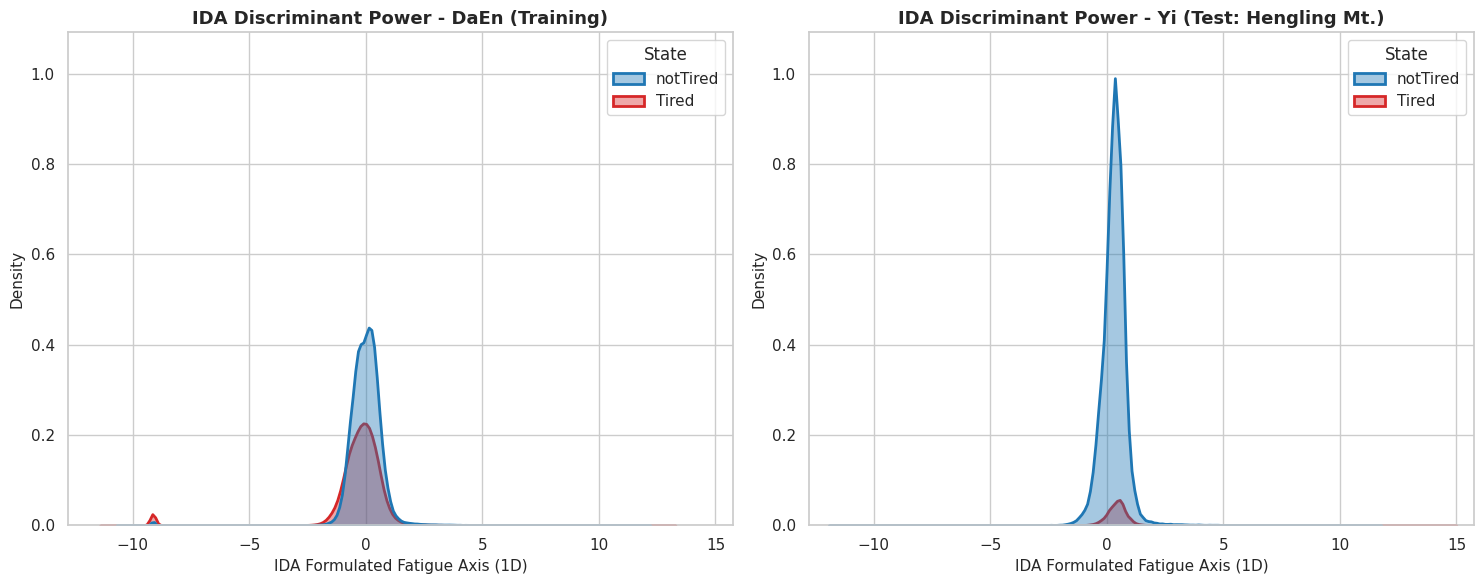

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 讀取先前儲存的特徵 CSV (確保資料存在)
# ==========================================
csv_path = "./pca_html/pca_features_for_IDA.csv"
if not os.path.exists(csv_path):
    print(f"找不到檔案 {csv_path}，請確認先前的一條龍程式是否有成功執行過！")
else:
    df_all = pd.read_csv(csv_path)

# ==========================================
# 2. 重新計算 IDA 降維特徵 (確保模型與數據完全對齊)
# ==========================================
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
X_pc_features = df_all[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']]
y_labels = df_all['State']

ida = LinearDiscriminantAnalysis(n_components=1)
df_all['IDA_Feature'] = ida.fit_transform(X_pc_features, y_labels)[:, 0]

# ==========================================
# 3. 嚴謹繪圖：強制對齊 X 軸與 Y 軸
# ==========================================
%matplotlib inline
sns.set_theme(style="whitegrid")

# 建立畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)
custom_palette = {'notTired': '#1f77b4', 'Tired': '#d62728'}

# 分別取出兩人的數據
df_daen = df_all[df_all['Student'] == 'DaEn']
df_yi = df_all[df_all['Student'] == 'Yi']

# ---- 步驟 A：先繪製圖表 ----
ax1 = axes[0]
sns.kdeplot(data=df_daen, x='IDA_Feature', hue='State', palette=custom_palette,
            fill=True, alpha=0.4, linewidth=2, ax=ax1)
ax1.set_title("IDA Discriminant Power - DaEn (Training)", fontsize=13, fontweight='bold')
ax1.set_xlabel("IDA Formulated Fatigue Axis (1D)", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)

ax2 = axes[1]
sns.kdeplot(data=df_yi, x='IDA_Feature', hue='State', palette=custom_palette,
            fill=True, alpha=0.4, linewidth=2, ax=ax2)
ax2.set_title("IDA Discriminant Power - Yi (Test: Hengling Mt.)", fontsize=13, fontweight='bold')
ax2.set_xlabel("IDA Formulated Fatigue Axis (1D)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)

# ---- 步驟 B：關鍵修正！動態找出兩圖 Y 軸的最大極限，並強制統一 ----
# 讀取 matplotlib 自動計算出的 Y 軸上限，並取兩者最大值
y1_max = ax1.get_ylim()[1]
y2_max = ax2.get_ylim()[1]
global_y_max = max(y1_max, y2_max) * 1.05  # 微調留白 5% 避免山峰頂到邊框

# 強制將兩張圖的 Y 軸設定成完全一致
ax1.set_ylim(0, global_y_max)
ax2.set_ylim(0, global_y_max)

# 強制將兩張圖的 X 軸也設定成完全一致
global_x_min = df_all['IDA_Feature'].min() - 1
global_x_max = df_all['IDA_Feature'].max() + 1
ax1.set_xlim(global_x_min, global_x_max)
ax2.set_xlim(global_x_min, global_x_max)

plt.tight_layout()

# 覆蓋原本不嚴謹的圖檔
output_dir = "./pca_html"
image_output_path = os.path.join(output_dir, "ida_separation_result.png")
plt.savefig(image_output_path, dpi=300)

print(f"🖼️ ✅ 嚴謹版圖表（XY雙軸完全對齊）已重新儲存至: {image_output_path}")
plt.show()

🔄 正在讀取原始 CSV 資料...
⚖️ 正在進行原始 6 軸數據標準化...
🧠 正在使用原始 6 軸數據執行 LDA 判別分析...
📊 正在繪製雙軸對齊之密度對比圖...
🖼️ ✅ 原始數據 LDA 對比圖已儲存至: ./pca_html/lda_raw_separation_result.png


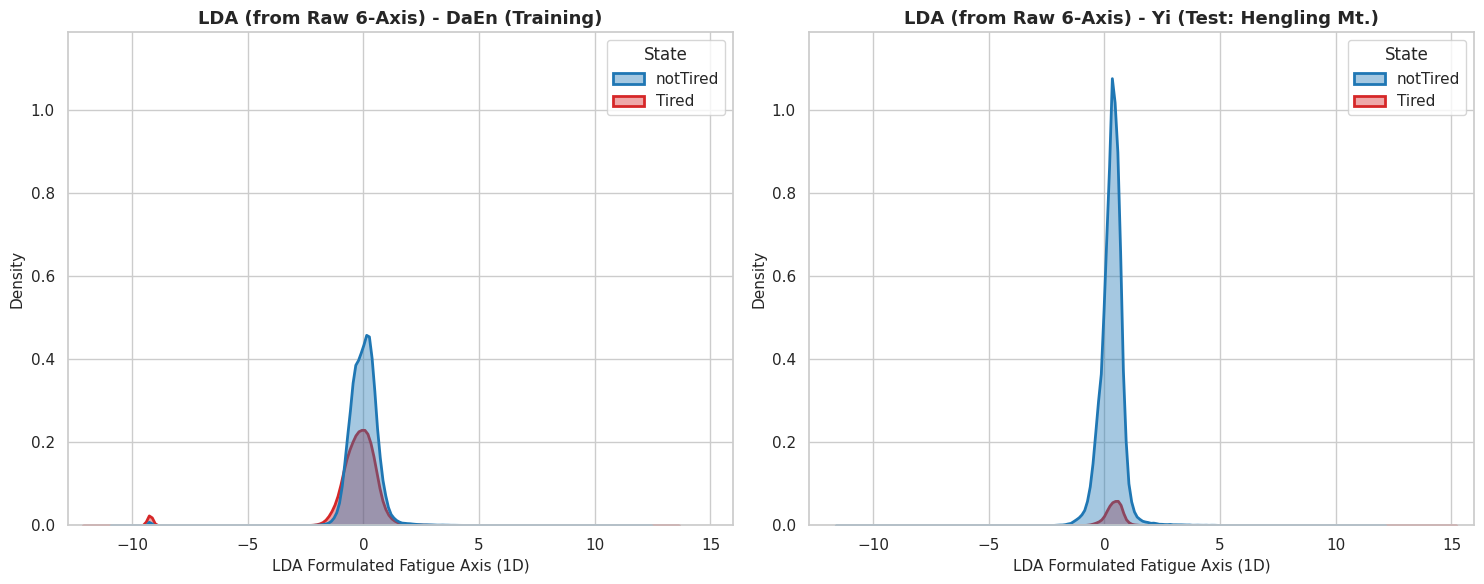

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ==========================================
# 1. 定義資料讀取函數 (回到源頭讀取原始數據)
# ==========================================
def load_data_from_folder(folder_path, student_label):
    combined_data = []
    if not os.path.exists(folder_path):
        print(f"警告：找不到路徑 {folder_path}")
        return pd.DataFrame()
        
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            
            if 'notTired' in file_name:
                state_label = 'notTired'
            elif 'Tired' in file_name:
                state_label = 'Tired'
            else:
                continue
            
            df['Student'] = student_label
            df['State'] = state_label
            df['Combined_Label'] = f"{student_label}_{state_label}"
            combined_data.append(df)
            
    if combined_data:
        return pd.concat(combined_data, ignore_index=True)
    else:
        return pd.DataFrame()

# ==========================================
# 2. 載入並整合原始 6 軸數據
# ==========================================
path_A = '../data_v58/test_data' 
path_B = './test_data_hengling_yi'

print("🔄 正在讀取原始 CSV 資料...")
df_A = load_data_from_folder(path_A, 'DaEn')
df_B = load_data_from_folder(path_B, 'Yi')
df_all = pd.concat([df_A, df_B], ignore_index=True)

feature_cols = ['acceleration_X', 'acceleration_Y', 'acceleration_Z', 'gyroscope_X', 'gyroscope_Y', 'gyroscope_Z']
df_all = df_all.dropna(subset=feature_cols)

# 取出原始特徵與標籤
X_raw = df_all[feature_cols]
y_labels = df_all['State']

# ==========================================
# 3. 數據標準化 (極度重要！)
# 加速度(g)與陀螺儀(deg/s)單位不同，直接做LDA會被數值大的干擾
# ==========================================
print("⚖️ 正在進行原始 6 軸數據標準化...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ==========================================
# 4. 直接使用「原始數據」計算 LDA 降維特徵 (跳過 PCA)
# ==========================================
print("🧠 正在使用原始 6 軸數據執行 LDA 判別分析...")
lda = LinearDiscriminantAnalysis(n_components=1)
df_all['LDA_Feature'] = lda.fit_transform(X_scaled, y_labels)[:, 0]

# ==========================================
# 5. 嚴謹繪圖：強制對齊 X 軸與 Y 軸
# ==========================================
print("📊 正在繪製雙軸對齊之密度對比圖...")
%matplotlib inline
sns.set_theme(style="whitegrid")

# 建立畫布
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)
custom_palette = {'notTired': '#1f77b4', 'Tired': '#d62728'}

df_daen = df_all[df_all['Student'] == 'DaEn']
df_yi = df_all[df_all['Student'] == 'Yi']

# ---- 步驟 A：先繪製圖表 ----
ax1 = axes[0]
sns.kdeplot(data=df_daen, x='LDA_Feature', hue='State', palette=custom_palette,
            fill=True, alpha=0.4, linewidth=2, ax=ax1)
# 標題特別註明是 Raw 6-Axis，以區別之前的 PCA 版本
ax1.set_title("LDA (from Raw 6-Axis) - DaEn (Training)", fontsize=13, fontweight='bold')
ax1.set_xlabel("LDA Formulated Fatigue Axis (1D)", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)

ax2 = axes[1]
sns.kdeplot(data=df_yi, x='LDA_Feature', hue='State', palette=custom_palette,
            fill=True, alpha=0.4, linewidth=2, ax=ax2)
ax2.set_title("LDA (from Raw 6-Axis) - Yi (Test: Hengling Mt.)", fontsize=13, fontweight='bold')
ax2.set_xlabel("LDA Formulated Fatigue Axis (1D)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)

# ---- 步驟 B：動態找出兩圖 Y 軸的最大極限，並強制統一 ----
y1_max = ax1.get_ylim()[1]
y2_max = ax2.get_ylim()[1]
global_y_max = max(y1_max, y2_max) * 1.05  # 微調留白 5% 避免山峰頂到邊框

# 強制將兩張圖的 Y 軸設定成完全一致
ax1.set_ylim(0, global_y_max)
ax2.set_ylim(0, global_y_max)

# 強制將兩張圖的 X 軸設定成完全一致
global_x_min = df_all['LDA_Feature'].min() - 1
global_x_max = df_all['LDA_Feature'].max() + 1
ax1.set_xlim(global_x_min, global_x_max)
ax2.set_xlim(global_x_min, global_x_max)

plt.tight_layout()

# 儲存圖檔
output_dir = "./pca_html"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
image_output_path = os.path.join(output_dir, "lda_raw_separation_result.png")
plt.savefig(image_output_path, dpi=300)

print(f"🖼️ ✅ 原始數據 LDA 對比圖已儲存至: {image_output_path}")
plt.show()